# Session 12 — Keypoint & Pose Estimation
**Phase 3 | Week 8 | Computer Vision & AI Course**

---

## What We'll Cover Today

| Topic | Description |
|---|---|
| What is Pose Estimation? | Keypoints, skeleton graphs, use-cases |
| MediaPipe Pose | Landmark detection on images & webcam |
| YOLOv8-pose | Multi-person pose estimation |
| Angles & Logic | Computing joint angles for real applications |
| Mini-Project | Simple rep-counter for bicep curls |

**Estimated time:** ~45 minutes hands-on

> 💡 **Goal:** By the end of this notebook you will be able to detect human body keypoints from an image or video stream and use those keypoints to build simple rule-based logic (e.g., counting exercise reps, detecting bad posture).

---
## 1. What is Pose Estimation?

Pose estimation is the task of **detecting the location of key body joints (keypoints)** in an image or video.

### Keypoints
A **keypoint** is a specific anatomical landmark on the human body — for example:
- Nose, eyes, ears
- Shoulders, elbows, wrists
- Hips, knees, ankles

Models typically detect **17 keypoints** (COCO format) or **33 keypoints** (MediaPipe BlazePose).

### Types of Pose Estimation

| Type | What it means | Example model |
|---|---|---|
| **Single-person** | Assumes one person in frame | MediaPipe Pose |
| **Multi-person** | Detects and tracks multiple people | YOLOv8-pose, OpenPose |
| **Top-down** | First detect people, then estimate pose per crop | Most YOLO-based |
| **Bottom-up** | Detect all keypoints first, then group into people | OpenPose |

### Real-World Applications
- 🏋️ **Fitness apps** — rep counting, form correction
- 💃 **Dance / AR** — motion capture, avatar animation
- 🏥 **Physiotherapy** — gait analysis, rehabilitation
- 🎮 **Gaming** — gesture control
- 🔒 **Security** — action recognition, fall detection

---
## 2. Setup & Installations

We'll use two libraries:
- **MediaPipe** — Google's lightweight pose estimation pipeline
- **Ultralytics (YOLOv8)** — for multi-person pose estimation

In [ ]:
# Install required libraries
# Run this cell only once
!pip install mediapipe opencv-python ultralytics matplotlib numpy -q

In [2]:
# Core imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.components import containers as mp_containers
from ultralytics import YOLO

# Helper: display images nicely in Jupyter
def show_image(img, title='Image', figsize=(10, 6)):
    """Display a BGR or RGB image using matplotlib."""
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("✅ Imports successful!")
print(f"   MediaPipe version: {mp.__version__}")

✅ Imports successful!
   MediaPipe version: 0.10.35


---
## 3. Download a Sample Image

We'll download a free-to-use image of a person to test pose estimation on.

✅ Image loaded: 598x387 pixels


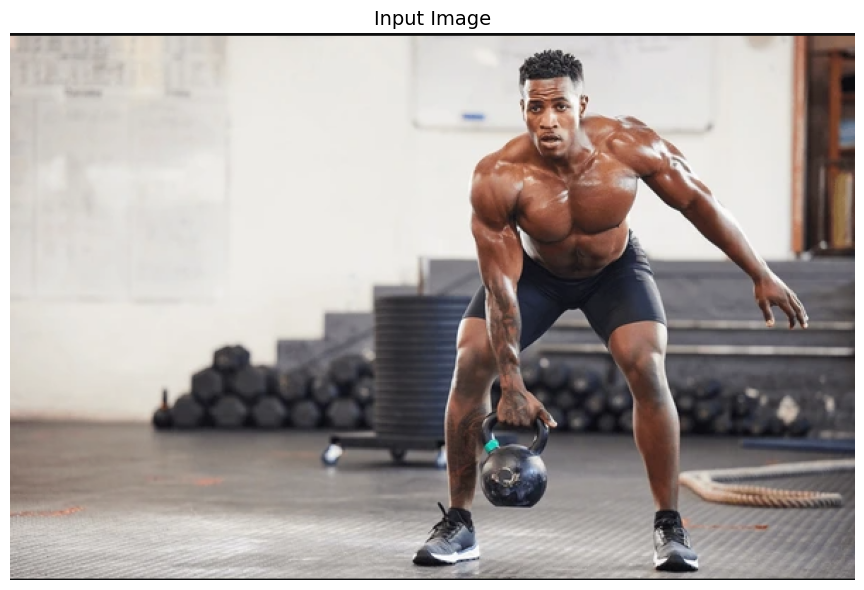

In [3]:
import urllib.request

# Download a sample image of a person (public domain)
image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/45/A_small_cup_of_coffee.JPG/640px-A_small_cup_of_coffee.JPG"

# NOTE: Replace this URL with any image of a person standing or exercising
# For example, download an image from Unsplash, Pexels, or use your own
# image_path = "person.jpg"  # local file path

# --- Better approach: use a real person image ---
# Let's use a publicly available yoga pose image
person_url = "https://images.unsplash.com/photo-1544367567-0f2fcb009e0b?w=640"

# Download the image
urllib.request.urlretrieve(person_url, "person.jpg")

# Load and display
img = cv2.imread("man.png")

if img is None:
    print("⚠️ Could not download image. Please place a 'person.jpg' file in this folder manually.")
    print("   Download any image of a person standing from: https://unsplash.com/s/photos/person-standing")
else:
    print(f"✅ Image loaded: {img.shape[1]}x{img.shape[0]} pixels")
    show_image(img, title="Input Image")

---
## 4. MediaPipe Pose

### What is MediaPipe?

MediaPipe is a Google framework for building ML pipelines for media data. The **Pose** solution detects **33 3D landmarks** (x, y, z + visibility) on the human body.

### How it works (simplified):
1. Detect a **bounding box** around the person
2. Crop and run a **landmark regression model** on the cropped region
3. Return 33 keypoints with (x, y, z, visibility)

### MediaPipe 33 Landmarks (BlazePose)

```
0: NOSE              16: LEFT_WRIST       
1: LEFT_EYE_INNER   17: RIGHT_WRIST      
2: LEFT_EYE         18: LEFT_PINKY       
3: LEFT_EYE_OUTER   ...                  
4: RIGHT_EYE_INNER  23: LEFT_HIP         
5: RIGHT_EYE        24: RIGHT_HIP        
6: RIGHT_EYE_OUTER  25: LEFT_KNEE        
7: LEFT_EAR         26: RIGHT_KNEE       
8: RIGHT_EAR        27: LEFT_ANKLE       
9: MOUTH_LEFT       28: RIGHT_ANKLE      
10: MOUTH_RIGHT     29: LEFT_HEEL        
11: LEFT_SHOULDER   30: RIGHT_HEEL       
12: RIGHT_SHOULDER  31: LEFT_FOOT_INDEX  
13: LEFT_ELBOW      32: RIGHT_FOOT_INDEX 
14: RIGHT_ELBOW     
15: LEFT_WRIST      
```

In [5]:
# ── MediaPipe Pose: Basic Detection (Tasks API) ───────────────────────────────
import urllib.request, os

# Download the MediaPipe pose landmarker model (runs once, ~6 MB)
MODEL_PATH = "pose_landmarker_full.task"
if not os.path.exists(MODEL_PATH):
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task",
        MODEL_PATH
    )
    print("✅ Model downloaded.")

# Step 1: Configure the landmarker
BaseOptions   = mp_python.BaseOptions
PoseLandmarker       = mp_vision.PoseLandmarker
PoseLandmarkerOptions = mp_vision.PoseLandmarkerOptions
RunningMode   = mp_vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=RunningMode.IMAGE,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

# Step 2: Load image and run detection
image = cv2.imread("man.png")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

with PoseLandmarker.create_from_options(options) as landmarker:
    detection_result = landmarker.detect(mp_image)

# Step 3: Check results
if detection_result.pose_landmarks:
    landmarks = detection_result.pose_landmarks[0]   # first person
    print(f"✅ Pose detected!  Landmarks: {len(landmarks)}")
    print("\n   First 5 landmarks (x, y, z, visibility):")
    LANDMARK_NAMES = [lm.name for lm in mp.solutions.pose.PoseLandmark] if hasattr(mp, 'solutions') else \
        ['NOSE','LEFT_EYE_INNER','LEFT_EYE','LEFT_EYE_OUTER','RIGHT_EYE_INNER',
         'RIGHT_EYE','RIGHT_EYE_OUTER','LEFT_EAR','RIGHT_EAR','MOUTH_LEFT','MOUTH_RIGHT',
         'LEFT_SHOULDER','RIGHT_SHOULDER','LEFT_ELBOW','RIGHT_ELBOW','LEFT_WRIST',
         'RIGHT_WRIST','LEFT_PINKY','RIGHT_PINKY','LEFT_INDEX','RIGHT_INDEX','LEFT_THUMB',
         'RIGHT_THUMB','LEFT_HIP','RIGHT_HIP','LEFT_KNEE','RIGHT_KNEE','LEFT_ANKLE',
         'RIGHT_ANKLE','LEFT_HEEL','RIGHT_HEEL','LEFT_FOOT_INDEX','RIGHT_FOOT_INDEX']
    for i, lm in enumerate(landmarks[:5]):
        print(f"   {LANDMARK_NAMES[i]:25s}  x={lm.x:.3f}  y={lm.y:.3f}  visibility={lm.visibility:.3f}")
else:
    print("⚠️  No pose detected. Try a different image with a clearly visible person.")

✅ Pose detected!  Landmarks: 33

   First 5 landmarks (x, y, z, visibility):
   NOSE                       x=0.641  y=0.162  visibility=1.000
   LEFT_EYE_INNER             x=0.648  y=0.137  visibility=1.000
   LEFT_EYE                   x=0.653  y=0.135  visibility=1.000
   LEFT_EYE_OUTER             x=0.658  y=0.134  visibility=1.000
   RIGHT_EYE_INNER            x=0.631  y=0.139  visibility=1.000


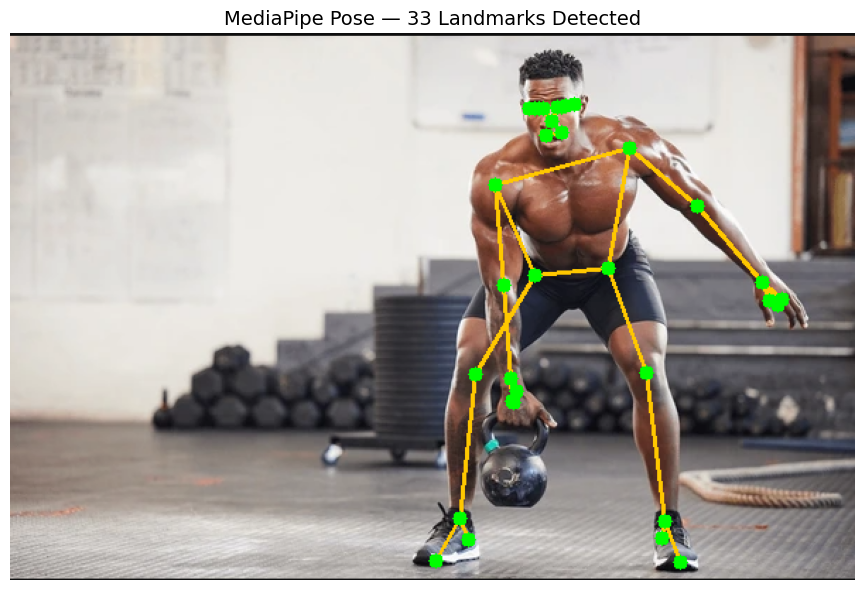

In [6]:
# ── MediaPipe Pose: Draw the skeleton (Tasks API) ────────────────────────────

# MediaPipe 0.10+ provides a utility specifically for Tasks API results
from mediapipe.tasks.python.vision.pose_landmarker import PoseLandmarkerResult

def draw_landmarks_on_image(bgr_image, detection_result):
    """Draw MediaPipe pose landmarks on a BGR image using the Tasks API result."""
    annotated = bgr_image.copy()
    if not detection_result.pose_landmarks:
        return annotated

    h, w = annotated.shape[:2]

    # BlazePose skeleton connections (index pairs)
    CONNECTIONS = [
        (0,1),(1,2),(2,3),(3,7),          # face left
        (0,4),(4,5),(5,6),(6,8),          # face right
        (9,10),                            # mouth
        (11,12),                           # shoulders
        (11,13),(13,15),                   # left arm
        (12,14),(14,16),                   # right arm
        (15,17),(15,19),(15,21),           # left hand
        (16,18),(16,20),(16,22),           # right hand
        (11,23),(12,24),(23,24),           # torso
        (23,25),(25,27),(27,29),(27,31),   # left leg
        (24,26),(26,28),(28,30),(28,32),   # right leg
    ]

    for pose_landmarks in detection_result.pose_landmarks:
        # Draw bones
        for (i, j) in CONNECTIONS:
            if i < len(pose_landmarks) and j < len(pose_landmarks):
                lm_i = pose_landmarks[i]
                lm_j = pose_landmarks[j]
                if lm_i.visibility > 0.3 and lm_j.visibility > 0.3:
                    pt1 = (int(lm_i.x * w), int(lm_i.y * h))
                    pt2 = (int(lm_j.x * w), int(lm_j.y * h))
                    cv2.line(annotated, pt1, pt2, (0, 200, 255), 2)

        # Draw keypoint dots
        for lm in pose_landmarks:
            if lm.visibility > 0.3:
                cx, cy = int(lm.x * w), int(lm.y * h)
                cv2.circle(annotated, (cx, cy), 5, (0, 255, 0), -1)

    return annotated


annotated = draw_landmarks_on_image(image, detection_result)
show_image(annotated, title="MediaPipe Pose — 33 Landmarks Detected")

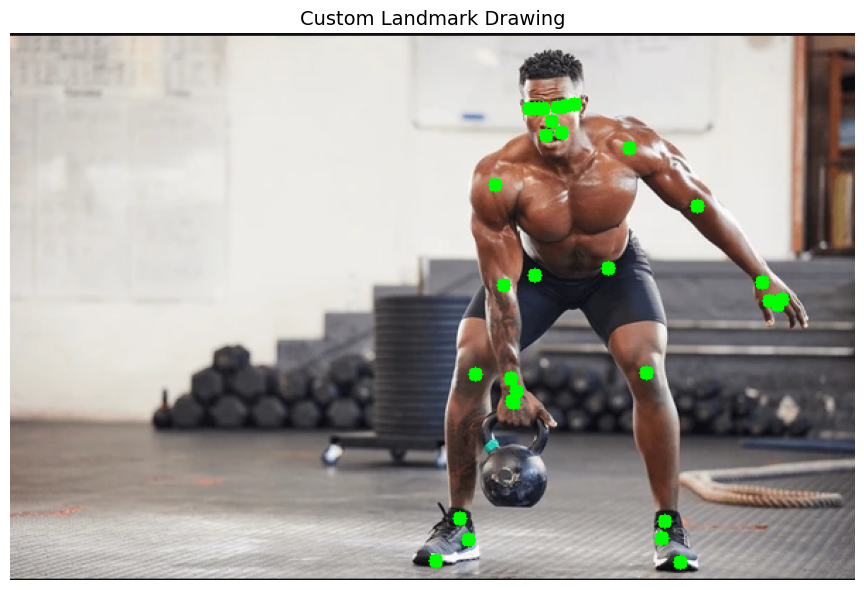

In [7]:
# ── MediaPipe Pose: Custom Drawing ───────────────────────────────────────────
# Draw landmarks manually to understand how normalised coordinates work.

def draw_pose_custom(bgr_image, pose_landmarks, color=(0, 255, 0), radius=5):
    """
    Manually draw pose landmarks on an image.
    Landmark coordinates are normalised (0.0–1.0); multiply by image size for pixels.
    """
    h, w = bgr_image.shape[:2]
    output = bgr_image.copy()
    for lm in pose_landmarks:
        cx = int(lm.x * w)
        cy = int(lm.y * h)
        if lm.visibility > 0.5:
            cv2.circle(output, (cx, cy), radius, color, -1)
    return output


custom_annotated = image.copy()
if detection_result.pose_landmarks:
    custom_annotated = draw_pose_custom(custom_annotated, detection_result.pose_landmarks[0])
show_image(custom_annotated, title="Custom Landmark Drawing")

---
## 5. Computing Joint Angles

One of the most useful things we can do with keypoints is **compute angles between joints**. This lets us:
- Check if an elbow is bent (curl rep counting)
- Detect bad posture (back angle)
- Classify exercises (is the arm straight or bent?)

### The Math
Given three points A, B, C (where B is the joint/vertex), the angle at B is:

```
         A
         |
         |  ← angle here
         B ——— C
```

We compute it using the **dot product** or `np.arctan2`:
```
angle = arctan2(C.y - B.y, C.x - B.x) - arctan2(A.y - B.y, A.x - B.x)
```

In [9]:
# ── Joint Angle Calculation ───────────────────────────────────────────────────

def calculate_angle(a, b, c):
    """
    Calculate the angle at point B, formed by points A → B → C.
    
    Parameters:
        a, b, c: each is a list/tuple of [x, y] coordinates
    
    Returns:
        angle in degrees (0–180)
    """
    a = np.array(a)  # point A (e.g., shoulder)
    b = np.array(b)  # point B — the JOINT we're measuring (e.g., elbow)
    c = np.array(c)  # point C (e.g., wrist)
    
    # arctan2 gives the angle of a vector from the positive x-axis
    # By taking the difference, we get the angle at B
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - \
              np.arctan2(a[1] - b[1], a[0] - b[0])
    
    angle = np.abs(np.degrees(radians))  # convert to degrees
    
    # Normalise to 0–180 range
    if angle > 180.0:
        angle = 360.0 - angle
    
    return angle


# Quick test
# 90-degree angle: A=(0,0), B=(0,1), C=(1,1)
test_angle = calculate_angle([0, 0], [0, 1], [1, 1])
print(f"Test angle (should be ~90°): {test_angle:.1f}°")

# 180-degree angle: A=(0,0), B=(1,0), C=(2,0) — straight line
test_angle_2 = calculate_angle([0, 0], [1, 0], [2, 0])
print(f"Test angle (should be ~180°): {test_angle_2:.1f}°")

Test angle (should be ~90°): 90.0°
Test angle (should be ~180°): 180.0°


Left Shoulder: [438, 81]
Left Elbow:    [486, 122]
Left Wrist:    [532, 176]

Elbow Angle: 170.9°
→ Arm is nearly STRAIGHT


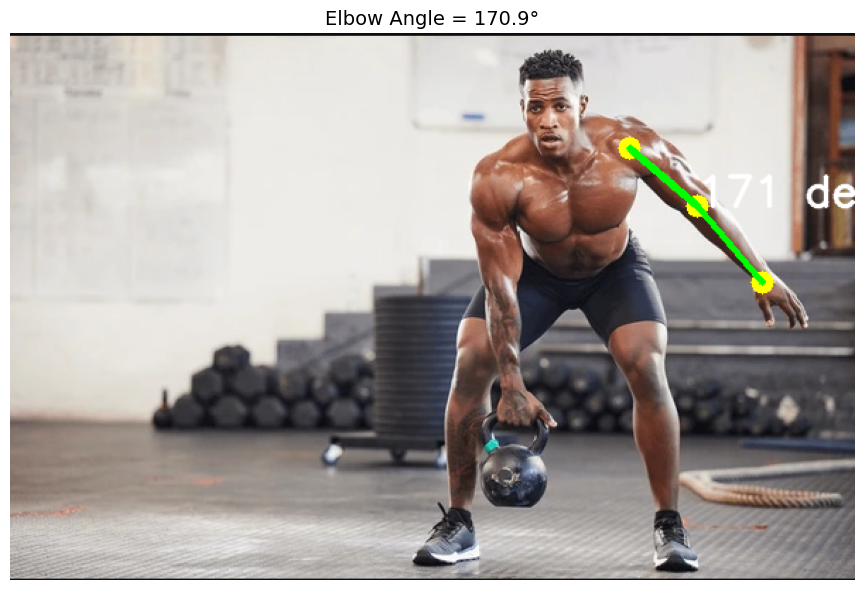

In [10]:
# ── Measure Elbow Angle from Detected Pose (Tasks API) ────────────────────────

# Landmark indices (same as before — BlazePose 33-point model)
LM = {
    'LEFT_SHOULDER': 11, 'RIGHT_SHOULDER': 12,
    'LEFT_ELBOW':    13, 'RIGHT_ELBOW':    14,
    'LEFT_WRIST':    15, 'RIGHT_WRIST':    16,
    'LEFT_HIP':      23, 'RIGHT_HIP':      24,
    'LEFT_KNEE':     25, 'RIGHT_KNEE':     26,
    'LEFT_ANKLE':    27, 'RIGHT_ANKLE':    28,
}

def get_landmark_coords(pose_landmarks, name, image_shape):
    """Return pixel [x, y] for a named landmark."""
    h, w = image_shape[:2]
    lm = pose_landmarks[LM[name]]
    return [int(lm.x * w), int(lm.y * h)]


if detection_result.pose_landmarks:
    lms = detection_result.pose_landmarks[0]

    shoulder = get_landmark_coords(lms, 'LEFT_SHOULDER', image.shape)
    elbow    = get_landmark_coords(lms, 'LEFT_ELBOW',    image.shape)
    wrist    = get_landmark_coords(lms, 'LEFT_WRIST',    image.shape)

    elbow_angle = calculate_angle(shoulder, elbow, wrist)

    print(f"Left Shoulder: {shoulder}")
    print(f"Left Elbow:    {elbow}")
    print(f"Left Wrist:    {wrist}")
    print(f"\nElbow Angle: {elbow_angle:.1f}°")

    if elbow_angle > 160:
        print("→ Arm is nearly STRAIGHT")
    elif elbow_angle < 50:
        print("→ Arm is fully CURLED (top of bicep curl)")
    else:
        print("→ Arm is partially bent")

    # Visualise
    angle_img = image.copy()
    cv2.putText(angle_img, f"{elbow_angle:.0f} deg", tuple(elbow),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
    for pt in [shoulder, elbow, wrist]:
        cv2.circle(angle_img, tuple(pt), 8, (0, 255, 255), -1)
    cv2.line(angle_img, tuple(shoulder), tuple(elbow), (0, 255, 0), 3)
    cv2.line(angle_img, tuple(elbow),    tuple(wrist),  (0, 255, 0), 3)
    show_image(angle_img, title=f"Elbow Angle = {elbow_angle:.1f}°")
else:
    print("No landmarks detected in image.")

---
## 6. Mini-Project — Bicep Curl Rep Counter

Now let's build something practical: a **bicep curl rep counter**.

### Logic:
- When the elbow angle goes **below a threshold** (arm curled up) → we register the "UP" phase
- When the elbow angle goes **above a threshold** (arm extended down) → we register the "DOWN" phase
- One full rep = UP → DOWN or DOWN → UP cycle

```
angle > 160° → "down" position
angle < 40°  → "up" position

Transition: down → up → down = 1 rep
```

In [11]:
# ── Bicep Curl Counter Class ───────────────────────────────────────────────────

class CurlCounter:
    """
    Counts bicep curl repetitions by tracking the left elbow angle.
    
    State machine:
        "down" → arm is extended (angle > 160°)
        "up"   → arm is curled   (angle < 40°)
    
    A rep is counted each time we complete a down→up→down or up→down→up cycle.
    """
    
    def __init__(self, up_threshold=40, down_threshold=160):
        self.up_threshold   = up_threshold    # angle below this = arm is curled UP
        self.down_threshold = down_threshold  # angle above this = arm is hanging DOWN
        self.counter = 0                      # total reps
        self.stage   = None                   # current stage: 'up' or 'down'
    
    def update(self, angle):
        """
        Feed in the current elbow angle and update the rep count.
        Returns the current rep count.
        """
        if angle > self.down_threshold:
            self.stage = 'down'
        
        if angle < self.up_threshold and self.stage == 'down':
            # We just went from down → up = one rep!
            self.stage = 'up'
            self.counter += 1
            print(f"   💪 Rep #{self.counter} counted!  (angle={angle:.1f}°)")
        
        return self.counter


# ── Simulate a workout (process a sequence of angles) ────────────────────────

# Simulate elbow angles during a workout
# (170 = arm down, 30 = arm fully curled)
simulated_angles = [
    170, 160, 140, 110, 80, 50, 30, 40,   # first rep: going up
    80, 110, 140, 160, 170,                # coming back down
    160, 130, 90, 50, 35, 25, 30,         # second rep
    60, 100, 140, 165, 170,               # back down
    160, 120, 70, 40, 28,                 # third rep
    50, 80, 120, 155, 170                 # back down
]

counter = CurlCounter(up_threshold=40, down_threshold=160)

print("Simulating workout...\n")
for angle in simulated_angles:
    counter.update(angle)

print(f"\n🏆 Total reps: {counter.counter}")

Simulating workout...

   💪 Rep #1 counted!  (angle=30.0°)
   💪 Rep #2 counted!  (angle=35.0°)
   💪 Rep #3 counted!  (angle=28.0°)

🏆 Total reps: 3


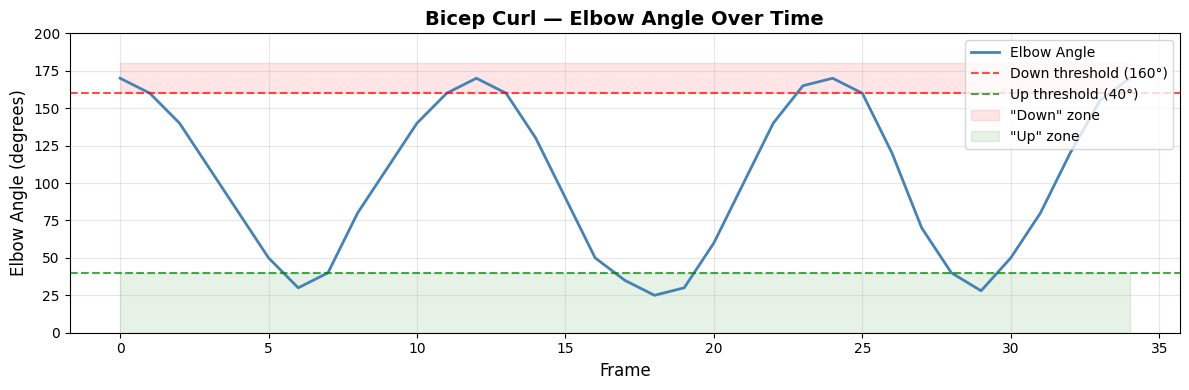

Total reps detected: 3


In [9]:
# ── Visualise the Angle Trace ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 4))

# Plot the angle over time
ax.plot(simulated_angles, color='steelblue', linewidth=2, label='Elbow Angle')

# Draw threshold lines
ax.axhline(y=160, color='red', linestyle='--', alpha=0.7, label='Down threshold (160°)')
ax.axhline(y=40,  color='green', linestyle='--', alpha=0.7, label='Up threshold (40°)')

# Fill regions
ax.fill_between(range(len(simulated_angles)), 160, 180,
                alpha=0.1, color='red', label='"Down" zone')
ax.fill_between(range(len(simulated_angles)), 0, 40,
                alpha=0.1, color='green', label='"Up" zone')

ax.set_xlabel('Frame', fontsize=12)
ax.set_ylabel('Elbow Angle (degrees)', fontsize=12)
ax.set_title('Bicep Curl — Elbow Angle Over Time', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 200)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total reps detected: {counter.counter}")

---
## 7. YOLOv8-pose — Multi-Person Pose Estimation

While MediaPipe is great for **single-person, real-time** use, **YOLOv8-pose** handles **multiple people** in a single forward pass.

### How it works:
YOLOv8-pose extends the detection head to also predict **17 keypoints** per bounding box (COCO format), all in a single pass.

### COCO 17 Keypoints:
```
0: Nose          5: L-Shoulder   10: R-Wrist   15: L-Ankle
1: L-Eye         6: R-Shoulder   11: L-Hip     16: R-Ankle  
2: R-Eye         7: L-Elbow      12: R-Hip     
3: L-Ear         8: R-Elbow      13: L-Knee    
4: R-Ear         9: L-Wrist      14: R-Knee    
```

### MediaPipe vs YOLOv8-pose:

| Feature | MediaPipe | YOLOv8-pose |
|---|---|---|
| Keypoints | 33 | 17 |
| Multi-person | ❌ (single person) | ✅ |
| 3D (depth) | ✅ | ❌ |
| Speed | Very fast (mobile) | Fast |
| Best for | Single-person, mobile, real-time | Multi-person scenes |

In [13]:
# ── YOLOv8-pose: Load Model & Run Inference ───────────────────────────────────

# Load the YOLOv8-pose model (downloads ~6 MB on first run)
# yolov8n-pose = nano (smallest & fastest), yolov8s-pose = small, etc.
model = YOLO('yolov8n-pose.pt')  # 'n' = nano variant

print("✅ YOLOv8-pose model loaded!")
print(f"   Model: YOLOv8 Nano Pose")
print(f"   Detects: 17 COCO keypoints per person")

✅ YOLOv8-pose model loaded!
   Model: YOLOv8 Nano Pose
   Detects: 17 COCO keypoints per person


In [14]:
# ── YOLOv8-pose: Inference on Image ──────────────────────────────────────────

# Run inference
results_yolo = model('man.png', verbose=False)

# Get the first result (one image → one result object)
result = results_yolo[0]

# Print what was detected
print(f"Number of people detected: {len(result.boxes)}")

# Access keypoints
if result.keypoints is not None:
    kpts = result.keypoints.xy.numpy()  # shape: [num_people, 17, 2]
    conf = result.keypoints.conf.numpy()  # shape: [num_people, 17]
    
    print(f"Keypoints shape: {kpts.shape}  → [people, keypoints, xy]")
    
    # Print keypoints for the first person
    if len(kpts) > 0:
        print("\nFirst person's keypoints (x, y, confidence):")
        kpt_names = ['Nose','L-Eye','R-Eye','L-Ear','R-Ear',
                     'L-Shoulder','R-Shoulder','L-Elbow','R-Elbow',
                     'L-Wrist','R-Wrist','L-Hip','R-Hip',
                     'L-Knee','R-Knee','L-Ankle','R-Ankle']
        for i, (pt, c) in enumerate(zip(kpts[0], conf[0])):
            print(f"  {kpt_names[i]:15s}  x={pt[0]:.1f}  y={pt[1]:.1f}  conf={c:.2f}")

Number of people detected: 1
Keypoints shape: (1, 17, 2)  → [people, keypoints, xy]

First person's keypoints (x, y, confidence):
  Nose             x=381.7  y=60.1  conf=0.99
  L-Eye            x=390.1  y=50.8  conf=0.98
  R-Eye            x=373.1  y=51.3  conf=0.96
  L-Ear            x=405.7  y=50.9  conf=0.86
  R-Ear            x=360.3  y=53.1  conf=0.61
  L-Shoulder       x=430.3  y=78.3  conf=1.00
  R-Shoulder       x=351.3  y=96.8  conf=0.99
  L-Elbow          x=487.3  y=112.2  conf=0.99
  R-Elbow          x=347.5  y=175.5  conf=0.97
  L-Wrist          x=534.1  y=167.7  conf=0.98
  R-Wrist          x=356.1  y=234.9  conf=0.94
  L-Hip            x=427.5  y=164.9  conf=1.00
  R-Hip            x=369.4  y=170.0  conf=1.00
  L-Knee           x=451.7  y=240.3  conf=1.00
  R-Knee           x=334.0  y=232.4  conf=1.00
  L-Ankle          x=470.1  y=351.3  conf=0.98
  R-Ankle          x=325.4  y=328.1  conf=0.97


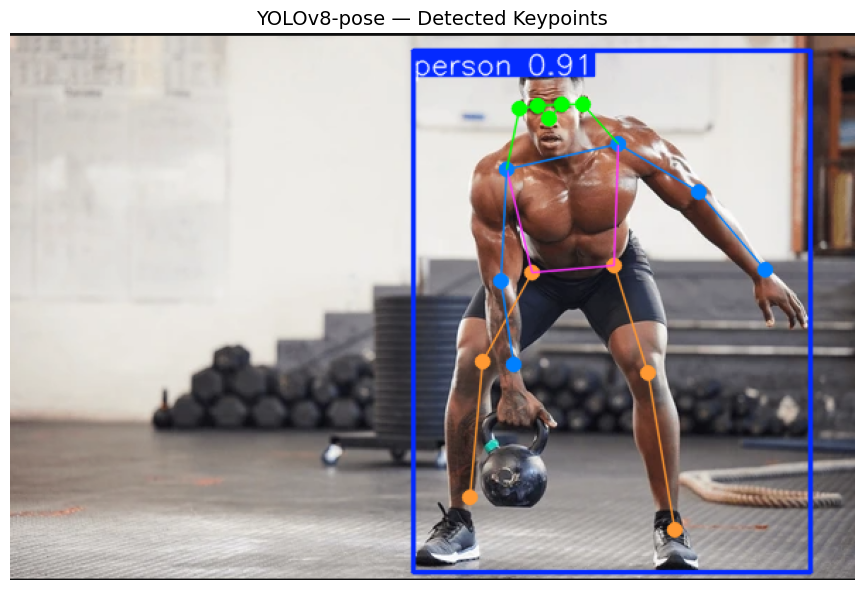

In [15]:
# ── YOLOv8-pose: Visualise Results ───────────────────────────────────────────

# The result object has a built-in plot() method — very convenient!
annotated_yolo = result.plot()

show_image(annotated_yolo, title="YOLOv8-pose — Detected Keypoints")

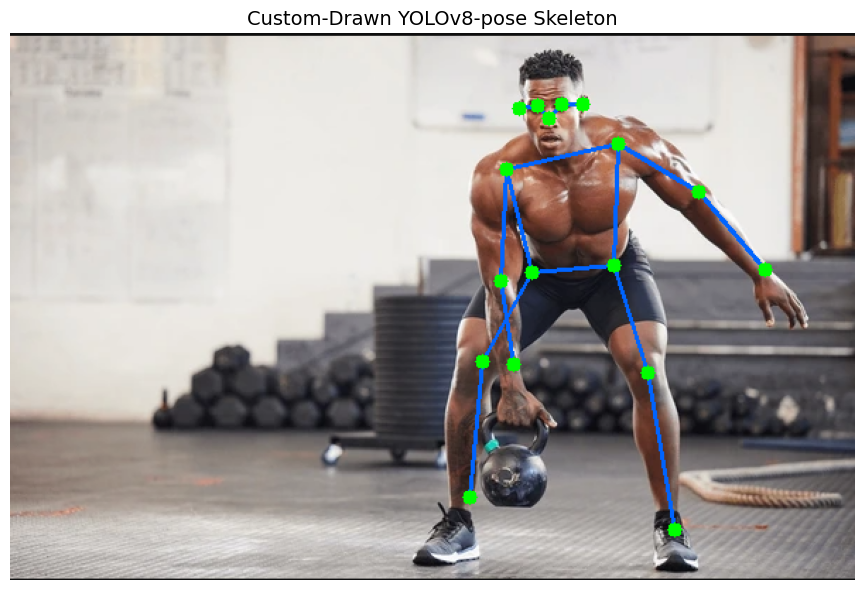

In [17]:
# ── YOLOv8-pose: Manual Drawing (Custom Colours) ─────────────────────────────

# COCO skeleton connections: list of (from_idx, to_idx) pairs
SKELETON = [
    (0, 1), (0, 2),           # nose → eyes
    (1, 3), (2, 4),           # eyes → ears
    (5, 6),                   # shoulders
    (5, 7), (7, 9),           # left arm
    (6, 8), (8, 10),          # right arm
    (5, 11), (6, 12),         # body
    (11, 12),                 # hips
    (11, 13), (13, 15),       # left leg
    (12, 14), (14, 16),       # right leg
]

def draw_yolo_pose(image, keypoints_xy, confidences, skeleton=SKELETON,
                   kpt_color=(0, 255, 0), bone_color=(255, 100, 0),
                   min_conf=0.3):
    """
    Draw keypoints and skeleton for one person detected by YOLOv8-pose.
    
    Parameters:
        keypoints_xy : np.array of shape (17, 2) — pixel coords
        confidences  : np.array of shape (17,)   — confidence per keypoint
    """
    img = image.copy()
    
    # Draw bones (skeleton connections)
    for (i, j) in skeleton:
        if confidences[i] > min_conf and confidences[j] > min_conf:
            pt1 = (int(keypoints_xy[i][0]), int(keypoints_xy[i][1]))
            pt2 = (int(keypoints_xy[j][0]), int(keypoints_xy[j][1]))
            cv2.line(img, pt1, pt2, bone_color, 2)
    
    # Draw keypoint dots
    for i, (pt, c) in enumerate(zip(keypoints_xy, confidences)):
        if c > min_conf:
            cx, cy = int(pt[0]), int(pt[1])
            cv2.circle(img, (cx, cy), 5, kpt_color, -1)
    
    return img


# Apply to our image
img_bgr = cv2.imread('man.png')
manual_result = img_bgr.copy()

if result.keypoints is not None and len(kpts) > 0:
    for person_idx in range(len(kpts)):  # iterate over all detected people
        manual_result = draw_yolo_pose(
            manual_result,
            kpts[person_idx],
            conf[person_idx]
        )

show_image(manual_result, title="Custom-Drawn YOLOv8-pose Skeleton")

---
## 8. Real-Time Pose Estimation (Webcam)

The code below runs pose estimation on your **live webcam feed**.

> 💡 Run this in a standalone `.py` script or in a terminal for best performance.
> Press **`q`** to quit the webcam window.

In [14]:
# ── Real-Time Pose Estimation — Webcam (Tasks API) ────────────────────────────
# NOTE: This opens a live window. Press 'q' to quit.

def run_pose_webcam(use_mediapipe=True):
    """
    Real-time pose estimation using either MediaPipe Tasks API or YOLOv8-pose.
    Press 'q' to quit.
    """
    cap = cv2.VideoCapture(0)
    counter = CurlCounter()

    if use_mediapipe:
        options = PoseLandmarkerOptions(
            base_options=BaseOptions(model_asset_path=MODEL_PATH),
            running_mode=RunningMode.VIDEO,
            min_pose_detection_confidence=0.5,
            min_pose_presence_confidence=0.5,
            min_tracking_confidence=0.5,
        )
        landmarker = PoseLandmarker.create_from_options(options)
    else:
        yolo_model = YOLO('yolov8n-pose.pt')

    frame_idx = 0
    print("Webcam started. Press 'q' to quit.")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if use_mediapipe:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_frame = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            # VIDEO mode requires a monotonically increasing timestamp in ms
            timestamp_ms = int(cap.get(cv2.CAP_PROP_POS_MSEC)) or frame_idx * 33
            result = landmarker.detect_for_video(mp_frame, timestamp_ms)

            if result.pose_landmarks:
                frame = draw_landmarks_on_image(frame, result)
                lms = result.pose_landmarks[0]
                shoulder = get_landmark_coords(lms, 'LEFT_SHOULDER', frame.shape)
                elbow    = get_landmark_coords(lms, 'LEFT_ELBOW',    frame.shape)
                wrist    = get_landmark_coords(lms, 'LEFT_WRIST',    frame.shape)
                angle = calculate_angle(shoulder, elbow, wrist)
                counter.update(angle)
                cv2.putText(frame, f'Angle: {angle:.0f}',
                            tuple(elbow), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
                cv2.putText(frame, f'Reps: {counter.counter}',
                            (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3)
                cv2.putText(frame, f'Stage: {counter.stage}',
                            (10, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 200, 255), 2)
        else:
            yolo_results = yolo_model(frame, verbose=False)
            frame = yolo_results[0].plot()

        cv2.imshow('Pose Estimation — Press Q to quit', frame)
        frame_idx += 1

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    if use_mediapipe:
        landmarker.close()
    print(f"Session ended. Total reps counted: {counter.counter}")


# Uncomment to run:
# run_pose_webcam(use_mediapipe=True)   # MediaPipe with curl counter
# run_pose_webcam(use_mediapipe=False)  # YOLOv8-pose

print("ℹ️ Webcam function defined. Uncomment the last line to run it.")

ℹ️ Webcam function defined. Uncomment the last line to run it.


---
## 9. MediaPipe vs YOLOv8-pose — Side-by-Side Comparison

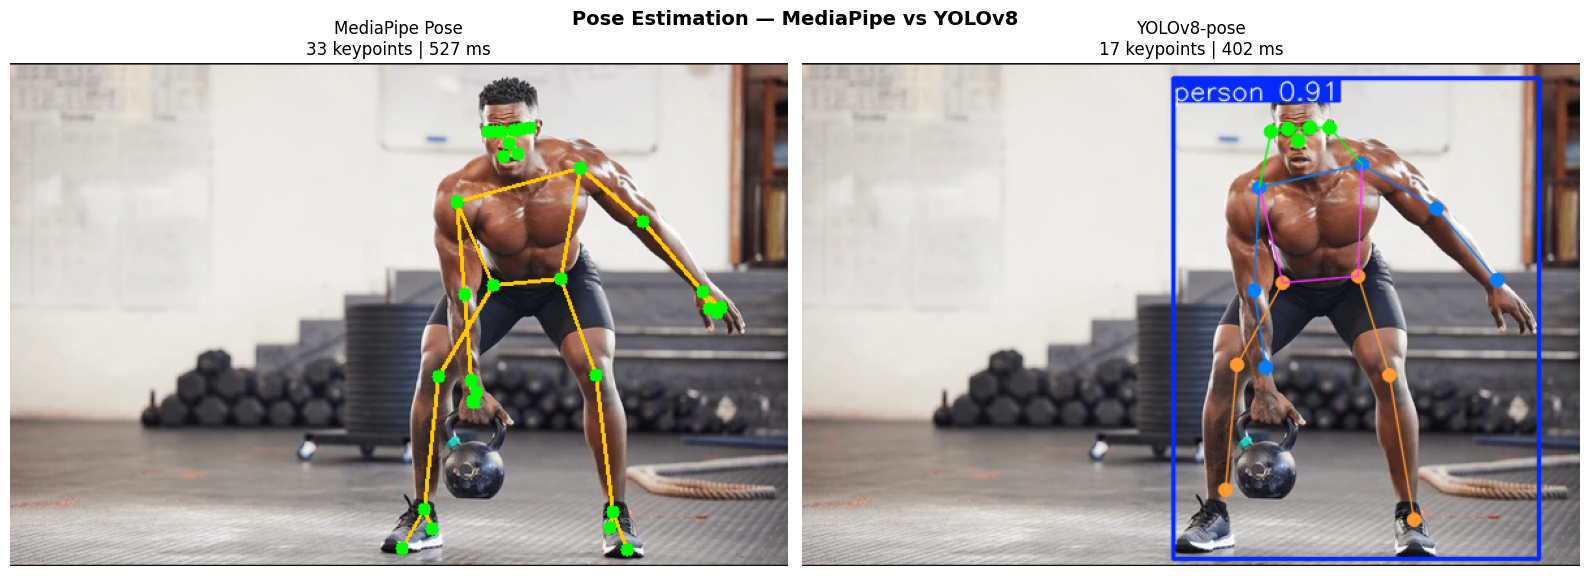

In [18]:
# ── Side-by-Side Comparison ───────────────────────────────────────────────────
import time

img = cv2.imread('man.png')

# ── MediaPipe ──
start = time.time()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
with PoseLandmarker.create_from_options(
    PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=RunningMode.IMAGE,
    )
) as lm:
    mp_result = lm.detect(mp_img)
mp_output = draw_landmarks_on_image(img, mp_result)   # uses pure-CV2 drawing, no framework import
mp_time = time.time() - start

# ── YOLOv8 ──
start = time.time()
yolo_results = model('man.png', verbose=False)
yolo_output = yolo_results[0].plot()
yolo_time = time.time() - start

# ── Display side by side ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(mp_output, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'MediaPipe Pose\n33 keypoints | {mp_time*1000:.0f} ms', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(yolo_output, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'YOLOv8-pose\n17 keypoints | {yolo_time*1000:.0f} ms', fontsize=12)
axes[1].axis('off')

plt.suptitle('Pose Estimation — MediaPipe vs YOLOv8', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Exercises 🏋️

Try these on your own to reinforce what you've learned:

1. **Knee angle tracker** — Modify the angle code to compute the *knee* angle instead of the elbow. Print whether the person is in a squat position.

2. **Posture detector** — Compute the angle between the left hip, left shoulder, and vertical axis. If the angle is large, print a warning: "Straighten your back!"

3. **Multi-person angle** — Use YOLOv8-pose on an image with 2+ people. Compute and display the elbow angle for each person.

4. **Plank detector** — Detect if a person is in a plank position by checking that hips are roughly aligned with shoulders and ankles (all at a similar y-coordinate).

5. **Overlay dashboard** — In the webcam feed, display a small info panel (like a fitness app) showing: current angle, rep count, and stage (UP / DOWN).

---
## Summary

| Concept | Key Takeaway |
|---|---|
| Pose estimation | Locating body keypoints (joints) in images/video |
| MediaPipe Pose | 33 landmarks, single-person, very fast, includes 3D depth |
| YOLOv8-pose | 17 COCO keypoints, multi-person, single-pass detection |
| Normalised coords | MediaPipe returns x/y as 0–1 fractions of image size |
| Joint angles | Use `arctan2` to compute angle at any joint from 3 points |
| Rep counting | Simple state machine: detect transitions between phases |